# Blood cell image classification with DP-SGD

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
%config InlineBackend.figure_formats=['svg']

import torch
import torchvision.transforms as transforms
import torch.utils.data as data
import medmnist
from medmnist import INFO, Evaluator

from utility import get_datasets, get_data_info, get_single_prediction, get_test_acc, denormalize
from model import get_model, load_model

## Data preparation

In [2]:
data_flag = 'bloodmnist'
info = get_data_info(data_flag)
n_channels = info['n_channels']
n_classes = len(info['label'])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load data 
_, _, test_dataset = get_datasets(data_flag)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=128, shuffle=False) # single example

# Load weights
non_private_weights_path = 'weights/non_private_model/model_init_2_best_epoch_41_auc_0.9972_acc_0.9568.pth'
private_weights_path = 'weights/final_model/model_init_1_best_epoch_58_auc_0.9670_acc_0.8043.pth' 

Using downloaded and verified file: /Users/anastasiia_popova/.medmnist/bloodmnist.npz
Using downloaded and verified file: /Users/anastasiia_popova/.medmnist/bloodmnist.npz
Using downloaded and verified file: /Users/anastasiia_popova/.medmnist/bloodmnist.npz


## Model loading and evaluation

In [3]:
non_private_model = load_model(non_private_weights_path, device)
private_model = load_model(private_weights_path, device)

AUC, ACC = get_test_acc(non_private_model, test_loader, info, data_flag)
AUC_privat, ACC_privat = get_test_acc(private_model, test_loader, info, data_flag)

print("---------------------------------------")
print(f"ACC of non private model is {ACC:.4f}")
print(f"ACC of private model is {ACC_privat:.4f}")

Using device: cpu
Using device: cpu
---------------------------------------
ACC of non private model is 0.9503
ACC of private model is 0.7983


## Prediction for a single example

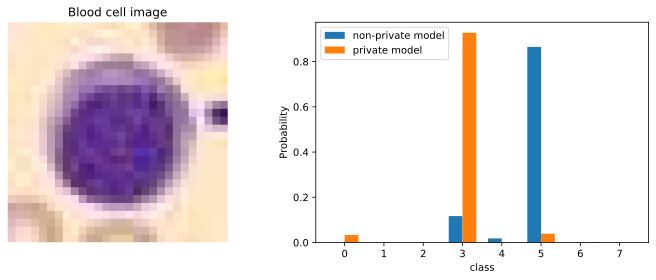

True label: immature granulocytes(myelocytes, metamyelocytes and promyelocytes)
Non-private model prediction: monocyte
Private model prediction (2, 7e-9): immature granulocytes(myelocytes, metamyelocytes and promyelocytes)


In [7]:
# get a random image index
image_idx = 122
class_names = info['label']

true_label, image, non_private_pred, non_private_probs = get_single_prediction(non_private_model, test_dataset, image_idx)
_, _, private_pred, private_probs = get_single_prediction(private_model, test_dataset, image_idx)


fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].imshow(denormalize(image).permute(1, 2, 0))  # CxHxW -> HxWxC
axs[0].set_title("Blood cell image")
axs[0].axis('off')

x = np.arange(len(class_names))
width = 0.35
axs[1].bar(x - width/2, non_private_probs, width, label='non-private model')
axs[1].bar(x + width/2, private_probs, width, label='private model')
axs[1].set_xticks(x)
axs[1].set_xticklabels(class_names.keys())
axs[1].set_xlabel('class')
axs[1].set_ylabel('Probability')
axs[1].legend()

plt.tight_layout()
plt.show()

print(f"True label: {class_names[str(true_label)]}")
print(f"Non-private model prediction: {class_names[str(non_private_pred)] }")
print(f"Private model prediction (2, 7e-9): {class_names[str(private_pred)]}")